In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# 1. Build your weighted interaction graph
# Nodes represent logical qubits, edges represent two-qubit gate interactions
G = nx.Graph()
G.add_edge('q0', 'q1', weight=1) # High interaction
G.add_edge('q0', 'q4', weight=3) # High interaction
G.add_edge('q0', 'q2', weight=1)
G.add_edge('q1', 'q2', weight=1)
# G.add_edge('q1', 'q3', weight=2)
# G.add_edge('q2', 'q3', weight=1)  # Weak interaction (boundary)
G.add_edge('q3', 'q4', weight=1)

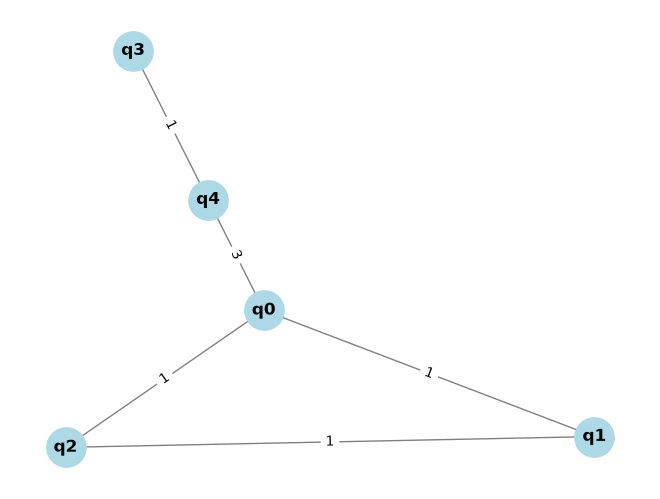

In [3]:
pos = nx.spring_layout(G)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=800,
    font_weight="bold",
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

In [4]:
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G, weight='weight')

for i, comm in enumerate(communities):
    print(f"Modality Sub-graph {i}: {comm}")

Modality Sub-graph 0: {'q2', 'q1'}
Modality Sub-graph 1: {'q3', 'q4', 'q0'}


In [5]:
# 1. Create a 'distance' attribute by inverting the interaction strength
for u, v, data in G.edges(data=True):
    interaction_strength = data['weight']
    # Add a small epsilon to avoid division by zero if weight is 0
    data['distance'] = 1.0 / interaction_strength if interaction_strength > 0 else float('inf')

# 2. Calculate Betweenness Centrality using the NEW 'distance' weight
centrality = nx.betweenness_centrality(G, weight='distance', normalized=True)

# Sort the qubits by their centrality score (descending)
sorted_centrality = dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

print("Betweenness Centrality Scores:")
for node, score in sorted_centrality.items():
    print(f"Qubit {node}: {score:.4f}")

Betweenness Centrality Scores:
Qubit q0: 0.6667
Qubit q4: 0.5000
Qubit q1: 0.0000
Qubit q2: 0.0000
Qubit q3: 0.0000


In [7]:
from qiskit import QuantumCircuit


def build_interaction_graph(circuit: QuantumCircuit) -> nx.Graph:
    num_qubits = circuit.num_qubits
    wig = nx.Graph()

    wig.add_nodes_from(range(num_qubits))

    for instr in circuit.data:
        qubits_involved = instr.qubits

        indices = [circuit.find_bit(q).index for q in qubits_involved]

        if wig.has_edge(indices[0], indices[1]):
            print(indices[0], indices[1])
            wig[indices[0]][indices[1]]['weight'] += 1
        else:
            wig.add_edge(indices[0], indices[1], weight = 1)
    
    return wig

In [8]:
# Create a circuit with 5 qubits
qc = QuantumCircuit(5)

# Cluster 1 (Qubits 0, 1, 2) - Heavy interaction
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.cx(0, 1)
qc.cx(1, 2)

# Bridge / Boundary (Qubits 2, 3) - Weak interaction
qc.cz(2, 3) 

# Cluster 2 (Qubits 3, 4) - Heavy interaction
qc.cx(3, 4)
qc.cx(3, 4)
qc.cx(3, 4)

qc.draw()

q_0: ──■─────────■────■─────────────────────────
     ┌─┴─┐       │  ┌─┴─┐                       
q_1: ┤ X ├──■────┼──┤ X ├──■────────────────────
     └───┘┌─┴─┐┌─┴─┐└───┘┌─┴─┐                  
q_2: ─────┤ X ├┤ X ├─────┤ X ├─■────────────────
          └───┘└───┘     └───┘ │                
q_3: ──────────────────────────■───■────■────■──
                                 ┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ────────────────────────────┤ X ├┤ X ├┤ X ├
                                 └───┘└───┘└───┘

In [9]:
# Generate the interaction graph
interaction_graph = build_interaction_graph(qc)

# Print the resulting edges and their weights
print("Interaction Graph Edges:")
for u, v, data in interaction_graph.edges(data=True):
    print(f"Qubit {u} <---> Qubit {v} : Weight {data['weight']}")

0 1
1 2
3 4
3 4
Interaction Graph Edges:
Qubit 0 <---> Qubit 1 : Weight 2
Qubit 0 <---> Qubit 2 : Weight 1
Qubit 1 <---> Qubit 2 : Weight 2
Qubit 2 <---> Qubit 3 : Weight 1
Qubit 3 <---> Qubit 4 : Weight 3


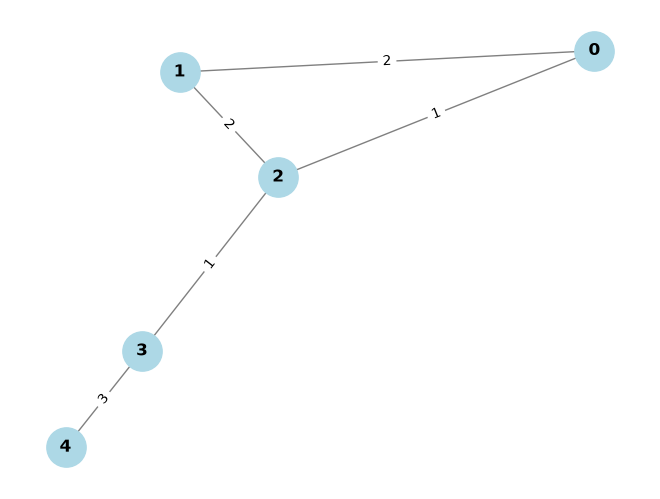

In [10]:
pos = nx.spring_layout(interaction_graph)

edge_labels = nx.get_edge_attributes(interaction_graph, "weight")

nx.draw(
    interaction_graph,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=800,
    font_weight="bold",
)

nx.draw_networkx_edge_labels(interaction_graph, pos, edge_labels=edge_labels)

plt.show()

In [11]:
communities = louvain_communities(interaction_graph, weight='weight')

for i, comm in enumerate(communities):
    print(f"Modality Sub-graph {i}: {comm}")

Modality Sub-graph 0: {0, 1, 2}
Modality Sub-graph 1: {3, 4}


In [12]:
# 1. Create a 'distance' attribute by inverting the interaction strength
for u, v, data in interaction_graph.edges(data=True):
    interaction_strength = data['weight']
    # Add a small epsilon to avoid division by zero if weight is 0
    data['distance'] = 1.0 / interaction_strength if interaction_strength > 0 else float('inf')

# 2. Calculate Betweenness Centrality using the NEW 'distance' weight
centrality = nx.betweenness_centrality(interaction_graph, weight='distance', normalized=True)

# Sort the qubits by their centrality score (descending)
sorted_centrality = dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

print("Betweenness Centrality Scores:")
for node, score in sorted_centrality.items():
    print(f"Qubit {node}: {score:.4f}")

Betweenness Centrality Scores:
Qubit 2: 0.6667
Qubit 3: 0.5000
Qubit 1: 0.2500
Qubit 0: 0.0000
Qubit 4: 0.0000
